In [1]:
import numpy as np
import matplotlib.pyplot as plt

import ismrmrd
import torch

import psutil
import subprocess
import os
import h5py  

import lxml.etree

In [2]:
CarryOustSim = True

The maximum amplitude is: 0.7238355
The area under the curve is: 0.20169243
The area under the curve for a rectangular pulse is: 0.7231117
The form factor of the pulse is: 0.27892295


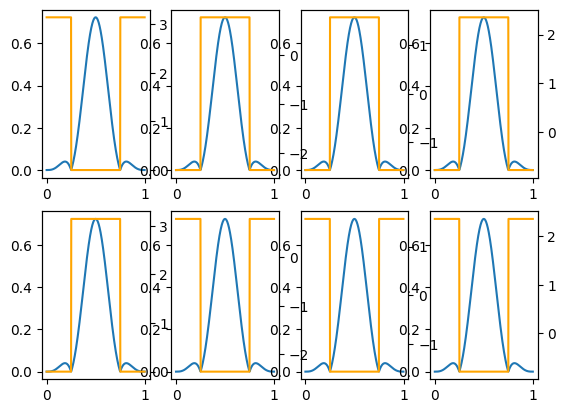

In [3]:
fig, axs = plt.subplots(2, 4)
for i in range(8):
    filename = f'CP_test/rf_1_ch{i}.h5'
    with h5py.File(filename,'r+') as f:
        dset = f['extpulse'][()]
        time = dset[0,:]
        amplitude = dset[1,:]
        phase = dset[2,:]
        axs.flat[i].plot(time, amplitude)
        ax2 = axs.flat[i].twinx()
        ax2.plot(time, phase, color='orange')

        # Write files with twice the angle
        dset2angle = dset.copy()
        dset2angle[1,:] = dset2angle[1,:] * 2
        filename_double = f'CP_test/rf_1_ch{i}_DA.h5'
        with h5py.File(filename_double,'w') as f_double:
            f_double.create_dataset('extpulse', data=dset2angle)


MaxMagnitude = np.max(np.abs(dset[1,:]))
print("The maximum amplitude is:", MaxMagnitude)

AreaUnderCurve = np.trapz(dset[1,:], time)
print("The area under the curve is:", AreaUnderCurve)

AreaUnderCurve_Rect = MaxMagnitude * (time[-1] - time[0])
print("The area under the curve for a rectangular pulse is:", AreaUnderCurve_Rect)

FormFactor = AreaUnderCurve / AreaUnderCurve_Rect
print("The form factor of the pulse is:", FormFactor)

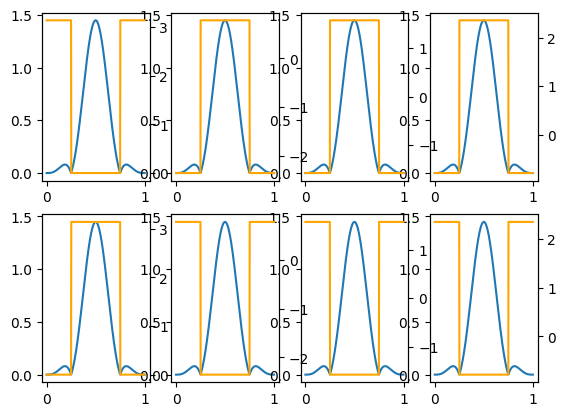

In [4]:
fig, axs = plt.subplots(2, 4)
for i in range(8):
    filename = f'CP_test/rf_1_ch{i}_DA.h5'
    with h5py.File(filename,'r+') as f:
        dset = f['extpulse'][()]
        time = dset[0,:]
        amplitude = dset[1,:]
        phase = dset[2,:]
        axs.flat[i].plot(time, amplitude)
        ax2 = axs.flat[i].twinx()
        ax2.plot(time, phase, color='orange')

In [5]:
# first file
filename = 'CP_test/CoilHE01.h5'
with h5py.File(filename,'r') as f:
    # print(f['maps'].keys())
    Sensmap = f['maps']['magnitude'][()] * np.exp(1j * f['maps']['phase'][()])

# remaining files
for i in range(1,8):
    filename = f'CP_test/CoilHE0{i+1}.h5'
    with h5py.File(filename,'r') as f:
        Sensmap += f['maps']['magnitude'][()] * np.exp(1j * ( f['maps']['phase'][()] + i * 45 * np.pi / 180))

# remove NaNs
Sensmap[np.isnan(Sensmap)] = 0

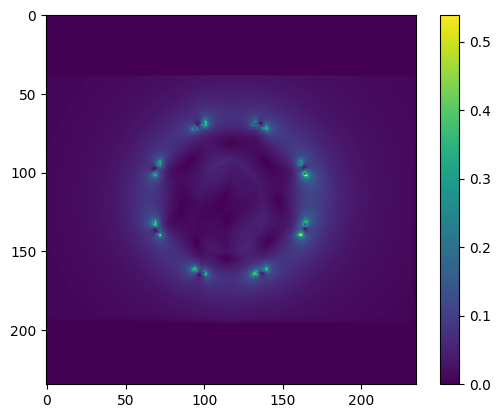

In [6]:
plt.imshow(np.abs(Sensmap), cmap='viridis')
plt.colorbar()

In [7]:
Average_Sensmap = np.mean(np.abs(Sensmap[Sensmap.shape[0]//2-10:Sensmap.shape[0]//2+10, Sensmap.shape[1]//2-10:Sensmap.shape[1]//2+10]))
print("The average sensitivity in the central 20x20 region is:", Average_Sensmap)

The average sensitivity in the central 20x20 region is: 0.016447663564918374


In [8]:
# Flip angle 
Flip_angle  = AreaUnderCurve * Average_Sensmap * 180 / np.pi
print("The flip angle is:", Flip_angle, "degrees") 

The flip angle is: 0.19007125813377582 degrees


In [9]:
# write sensitivity map to file with NaNs replaced by zeros
# remaining files
for i in range(8):
    filename = f'CP_test/CoilHE0{i+1}.h5'
    with h5py.File(filename,'r') as f:
        amplitude = f['maps']['magnitude'][()]
        phase = f['maps']['phase'][()]
        amplitude[np.isnan(amplitude)] = 0
        phase[np.isnan(phase)] = 0

        # write back to file
        filename = f'CP_test/CoilHE0{i+1}_noNaN.h5'
        with h5py.File(filename,'w') as f:
            f.create_dataset('maps/magnitude', data=amplitude)
            f.create_dataset('maps/phase', data=phase)



In [10]:
Target_Flip_angle = 60
Scaling_Factor = Target_Flip_angle / Flip_angle
print("The scaling factor to achieve the target flip angle is:", Scaling_Factor)

The scaling factor to achieve the target flip angle is: 315.67108351421996


In [11]:
xslt_root = lxml.etree.parse( 'CP_test/gre_CP_ExtPulse.xml' )
elems = xslt_root.findall("//EXTERNALRFPULSE")
for elem in elems:
    elem.attrib['Scale'] = str(Scaling_Factor)


/var/folders/x0/stdn8c895h99g4y89x6mmbvm0015kg/T/ipykernel_31442/1201065743.py:2: FutureWarning: This search incorrectly ignores the root element, and will be fixed in a future version.  If you rely on the current behaviour, change it to './/EXTERNALRFPULSE'
  elems = xslt_root.findall("//EXTERNALRFPULSE")


In [12]:
# write modified xml file
with open('CP_test/gre_CP_ExtPulse_Scaled.xml', 'w') as f:
    print( '<?xml version="1.0" encoding="utf-8"?>', file = f)
    print(lxml.etree.tostring(xslt_root, pretty_print=True, encoding='unicode'), file = f)

In [13]:
xslt_root = lxml.etree.parse( 'CP_test/gre_CP_ExtPulse_DA.xml' )
elems = xslt_root.findall("//EXTERNALRFPULSE")
for elem in elems:
    elem.attrib['Scale'] = str(Scaling_Factor)

/var/folders/x0/stdn8c895h99g4y89x6mmbvm0015kg/T/ipykernel_31442/2904490306.py:2: FutureWarning: This search incorrectly ignores the root element, and will be fixed in a future version.  If you rely on the current behaviour, change it to './/EXTERNALRFPULSE'
  elems = xslt_root.findall("//EXTERNALRFPULSE")


In [14]:
# write modified xml file
with open('CP_test/gre_CP_ExtPulse_DA_Scaled.xml', 'w') as f:
    print( '<?xml version="1.0" encoding="utf-8"?>', file = f)
    print(lxml.etree.tostring(xslt_root, pretty_print=True, encoding='unicode'), file = f)

In [15]:
iNump = psutil.cpu_count(logical=False)

if CarryOustSim:
    os.chdir('CP_test')
    subprocess.run(["mpirun", "-np", str(iNump), "pjemris", "simu.xml"])
    os.chdir('..')
    os.rename('CP_test/signals_ismrmrd.h5', 'CP_test/signals_ismrmrd_FA1.h5')


Parallel jemris 2.9.2 (b0b3084267c41df80e4799beb7378060a0b8f60d)

Model    : Bloch	  , solver = CVODE
Sample   : user defined	  , spins  = 17645
TxArray  : CSTEfficiencies.xml
RxArray  : /usr/local/share/jemris/matlab/uniform.xml
Sequence : gre_CP_ExtPulse_Scaled.xml

Mac.fritz.box -> Master Process: send MR sample (17645 spins) to 11 slave(s)

Simulating | ************************************************** | 100% done

Actual simulation took 6138.53 seconds.


In [16]:
dset = ismrmrd.Dataset('CP_test/signals_ismrmrd_FA1.h5', 'dataset', create_if_needed=False)

In [17]:
# extract the header
header = ismrmrd.xsd.CreateFromDocument(dset.read_xml_header())
enc = header.encoding[0]

# Matrix size
eNx = enc.encodedSpace.matrixSize.x
eNy = enc.encodedSpace.matrixSize.y
eNz = enc.encodedSpace.matrixSize.z
rNx = enc.reconSpace.matrixSize.x
rNy = enc.reconSpace.matrixSize.y
rNz = enc.reconSpace.matrixSize.z

if(header.acquisitionSystemInformation.systemVendor == 'JEMRIS'):
    # Adjust for JEMRIS double matrix size bug
    # eNx = eNx // 2
    # eNy = eNy // 2
    # eNz = eNz // 2
    # rNx = rNx // 2
    # rNy = rNy // 2
    # rNz = rNz // 2
    if(eNx==0):
        eNx = 1
    if(eNy==0):
        eNy = 1
    if(eNz==0):
        eNz = 1
    if(rNx==0):
        rNx = 1
    if(rNy==0):
        rNy = 1
    if(rNz==0):
        rNz = 1
        
# Field of View
eFOVx = enc.encodedSpace.fieldOfView_mm.x
eFOVy = enc.encodedSpace.fieldOfView_mm.y
eFOVz = enc.encodedSpace.fieldOfView_mm.z
rFOVx = enc.reconSpace.fieldOfView_mm.x
rFOVy = enc.reconSpace.fieldOfView_mm.y
rFOVz = enc.reconSpace.fieldOfView_mm.z

# Number of Slices, Reps, Contrasts, etc.
if header.acquisitionSystemInformation.receiverChannels != None:        # Attention: This flag is not handled correctly by JEMRIS. We will treat this later.
    ncoils = header.acquisitionSystemInformation.receiverChannels
else:
    ncoils = 1

if enc.encodingLimits.slice != None:
    nslices = enc.encodingLimits.slice.maximum + 1
else:
    nslices = 1

if enc.encodingLimits.repetition != None:
    nreps = enc.encodingLimits.repetition.maximum + 1
else:
    nreps = 1

if enc.encodingLimits.set != None:
    nsets = enc.encodingLimits.set.maximum + 1
else:
    nsets = 1

if enc.encodingLimits.contrast != None:
    ncontrasts = enc.encodingLimits.contrast.maximum + 1
else:
    ncontrasts = 1

print('Parameters dertermined from the raw data file:')
print('FOV (x,y,z) = {},{},{}'.format(rFOVx, rFOVy, rFOVz))
print('Encoding matrix size (x,y,z) = {},{},{}'.format(eNx, eNy, eNz))
print('Image matrix size (x,y,z) = {},{},{}'.format(rNx, rNy, rNz))
print('Number of coils = {}'.format(ncoils))
print('Number of slices = {}'.format(nslices))
print('Number of repetitions = {}'.format(nreps))
print('Number of sets = {}'.format(nsets))
print('Number of contrasts = {}'.format(ncontrasts))

Parameters dertermined from the raw data file:
FOV (x,y,z) = 220.0,220.0,1.0
Encoding matrix size (x,y,z) = 64,64,1
Image matrix size (x,y,z) = 64,64,1
Number of coils = 1
Number of slices = 1
Number of repetitions = 1
Number of sets = 1
Number of contrasts = 1


In [18]:
# TODO loop through the acquisitions looking for noise scans
firstacq=0
for acqnum in range(dset.number_of_acquisitions()):

    acq = dset.read_acquisition(acqnum)
    
    # TODO: Currently ignoring noise scans
    if acq.isFlagSet(ismrmrd.ACQ_IS_NOISE_MEASUREMENT):
        print("Found noise scan at acq ", acqnum)
        continue
    else:
        firstacq = acqnum
        print("Imaging acquisition starts at acq ", acqnum)
        break

print('Numer of imaging k-sapce lines in the acquistion is {}'.format(dset.number_of_acquisitions()-firstacq))

Imaging acquisition starts at acq  0
Numer of imaging k-sapce lines in the acquistion is 65


In [19]:
# Get number of lines from header
nlines = (dset.number_of_acquisitions()-firstacq-1) 

acq = dset.read_acquisition(firstacq+1)
nsamples = len(acq.data[0])

# We are expecting nsets * ncontrasts * eNy data sets
nlines_expected = nsets * ncontrasts * eNy

if nlines != nlines_expected:
    firstacq = nlines - nlines_expected
    nlines = nlines_expected
    print("Start of imaging acquisition adopted to ", firstacq)
    print('Numer of imaging k-sapce lines in the acquistion adopted to {}'.format(dset.number_of_acquisitions()-firstacq))

print('Number of qcquistion lines reduced to {}'.format(nlines))
print('Number of samples per line is {}'.format(nsamples))

Number of qcquistion lines reduced to 64
Number of samples per line is 64


In [20]:
# Read first data line and get shape
acq = dset.read_acquisition(firstacq+1)
if np.ndim(acq.data) == 2:
    ncoils = acq.data.shape[0]
    if ncoils > 1:
        print('Receive coil array detected: \n\tThe header information for coil arrays is not set by JEMRIS, so that a coil array con only be detected using the k-spae data shape.')
        print('This data has {} receive channels. Adjusted ncoils accordingly.'.format(ncoils))

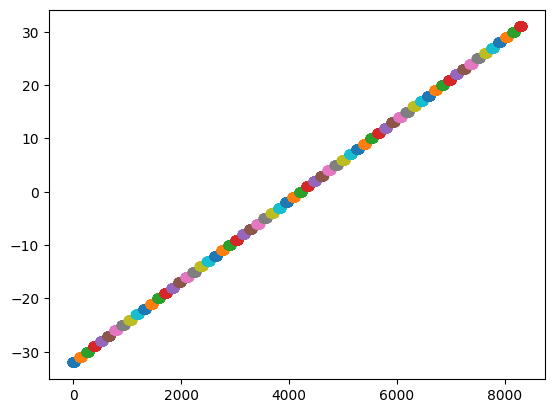

In [21]:
# Plot k-space lines
fig = plt.figure()
ax = plt.axes()

# Loop through the rest of the acquisitions and plot lines
for acqnum in range(firstacq + 1,dset.number_of_acquisitions()): 
    acq = dset.read_acquisition(acqnum)
    ax.scatter(acq.traj[:,0], acq.traj[:,1])
    # print('Acqnum {} has shape {}'.format(acqnum, acq.traj[:,0].shape[0]))

In [22]:
# preallocate storrage
all_data = np.zeros( (nlines, ncoils, nsamples), dtype=np.complex64 )
all_kspace = np.zeros( (nlines, nsamples, 3), dtype=np.complex64 )

# assign
for acqnum in range(firstacq + 1, dset.number_of_acquisitions()):
    acq = dset.read_acquisition(acqnum)
    all_data[acqnum-firstacq-1,:] = acq.data
    all_kspace[acqnum-firstacq-1,:,:] = acq.traj

In [23]:
dset.close()
rawdata = np.squeeze(all_data[:,0,:])

In [24]:
# fftshift FFT fftshift
spectrum = torch.fft.fftshift(torch.from_numpy(rawdata))
space = torch.fft.fft2(spectrum)
space_FA1 = torch.fft.ifftshift(space)


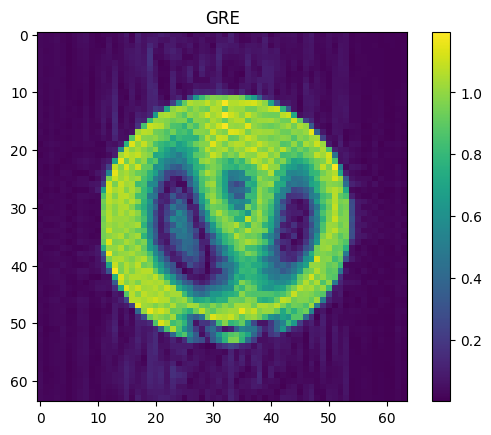

In [25]:
plt.title('GRE')
plt.imshow(np.abs(space_FA1.numpy()))
plt.colorbar()

In [28]:
iNump = psutil.cpu_count(logical=False)

if CarryOustSim:
    os.chdir('CP_test')
    subprocess.run(["mpirun", "-np", str(iNump), "pjemris", "simu_DA.xml"])
    os.chdir('..')
    os.rename('CP_test/signals_ismrmrd.h5', 'CP_test/signals_ismrmrd_FA2.h5')


Parallel jemris 2.9.2 (b0b3084267c41df80e4799beb7378060a0b8f60d)

Model    : Bloch	  , solver = CVODE
Sample   : user defined	  , spins  = 17645
TxArray  : CSTEfficiencies.xml
RxArray  : /usr/local/share/jemris/matlab/uniform.xml
Sequence : gre_CP_ExtPulse_DA_Scaled.xml

Mac.fritz.box -> Master Process: send MR sample (17645 spins) to 11 slave(s)

Simulating | ************************************************** | 100% done

Actual simulation took 9022.85 seconds.


In [29]:
dset = ismrmrd.Dataset('CP_test/signals_ismrmrd_FA2.h5', 'dataset', create_if_needed=False)

In [30]:
# extract the header
header = ismrmrd.xsd.CreateFromDocument(dset.read_xml_header())
enc = header.encoding[0]

# Matrix size
eNx = enc.encodedSpace.matrixSize.x
eNy = enc.encodedSpace.matrixSize.y
eNz = enc.encodedSpace.matrixSize.z
rNx = enc.reconSpace.matrixSize.x
rNy = enc.reconSpace.matrixSize.y
rNz = enc.reconSpace.matrixSize.z

if(header.acquisitionSystemInformation.systemVendor == 'JEMRIS'):
    # Adjust for JEMRIS double matrix size bug
    # eNx = eNx // 2
    # eNy = eNy // 2
    # eNz = eNz // 2
    # rNx = rNx // 2
    # rNy = rNy // 2
    # rNz = rNz // 2
    if(eNx==0):
        eNx = 1
    if(eNy==0):
        eNy = 1
    if(eNz==0):
        eNz = 1
    if(rNx==0):
        rNx = 1
    if(rNy==0):
        rNy = 1
    if(rNz==0):
        rNz = 1
        
# Field of View
eFOVx = enc.encodedSpace.fieldOfView_mm.x
eFOVy = enc.encodedSpace.fieldOfView_mm.y
eFOVz = enc.encodedSpace.fieldOfView_mm.z
rFOVx = enc.reconSpace.fieldOfView_mm.x
rFOVy = enc.reconSpace.fieldOfView_mm.y
rFOVz = enc.reconSpace.fieldOfView_mm.z

# Number of Slices, Reps, Contrasts, etc.
if header.acquisitionSystemInformation.receiverChannels != None:        # Attention: This flag is not handled correctly by JEMRIS. We will treat this later.
    ncoils = header.acquisitionSystemInformation.receiverChannels
else:
    ncoils = 1

if enc.encodingLimits.slice != None:
    nslices = enc.encodingLimits.slice.maximum + 1
else:
    nslices = 1

if enc.encodingLimits.repetition != None:
    nreps = enc.encodingLimits.repetition.maximum + 1
else:
    nreps = 1

if enc.encodingLimits.set != None:
    nsets = enc.encodingLimits.set.maximum + 1
else:
    nsets = 1

if enc.encodingLimits.contrast != None:
    ncontrasts = enc.encodingLimits.contrast.maximum + 1
else:
    ncontrasts = 1

print('Parameters dertermined from the raw data file:')
print('FOV (x,y,z) = {},{},{}'.format(rFOVx, rFOVy, rFOVz))
print('Encoding matrix size (x,y,z) = {},{},{}'.format(eNx, eNy, eNz))
print('Image matrix size (x,y,z) = {},{},{}'.format(rNx, rNy, rNz))
print('Number of coils = {}'.format(ncoils))
print('Number of slices = {}'.format(nslices))
print('Number of repetitions = {}'.format(nreps))
print('Number of sets = {}'.format(nsets))
print('Number of contrasts = {}'.format(ncontrasts))

Parameters dertermined from the raw data file:
FOV (x,y,z) = 220.0,220.0,1.0
Encoding matrix size (x,y,z) = 64,64,1
Image matrix size (x,y,z) = 64,64,1
Number of coils = 1
Number of slices = 1
Number of repetitions = 1
Number of sets = 1
Number of contrasts = 1


In [31]:
# TODO loop through the acquisitions looking for noise scans
firstacq=0
for acqnum in range(dset.number_of_acquisitions()):

    acq = dset.read_acquisition(acqnum)
    
    # TODO: Currently ignoring noise scans
    if acq.isFlagSet(ismrmrd.ACQ_IS_NOISE_MEASUREMENT):
        print("Found noise scan at acq ", acqnum)
        continue
    else:
        firstacq = acqnum
        print("Imaging acquisition starts at acq ", acqnum)
        break

print('Numer of imaging k-sapce lines in the acquistion is {}'.format(dset.number_of_acquisitions()-firstacq))

Imaging acquisition starts at acq  0
Numer of imaging k-sapce lines in the acquistion is 65


In [32]:
# Get number of lines from header
nlines = (dset.number_of_acquisitions()-firstacq-1) 

acq = dset.read_acquisition(firstacq+1)
nsamples = len(acq.data[0])

# We are expecting nsets * ncontrasts * eNy data sets
nlines_expected = nsets * ncontrasts * eNy

if nlines != nlines_expected:
    firstacq = nlines - nlines_expected
    nlines = nlines_expected
    print("Start of imaging acquisition adopted to ", firstacq)
    print('Numer of imaging k-sapce lines in the acquistion adopted to {}'.format(dset.number_of_acquisitions()-firstacq))

print('Number of qcquistion lines reduced to {}'.format(nlines))
print('Number of samples per line is {}'.format(nsamples))

Number of qcquistion lines reduced to 64
Number of samples per line is 64


In [33]:
# Read first data line and get shape
acq = dset.read_acquisition(firstacq+1)
if np.ndim(acq.data) == 2:
    ncoils = acq.data.shape[0]
    if ncoils > 1:
        print('Receive coil array detected: \n\tThe header information for coil arrays is not set by JEMRIS, so that a coil array con only be detected using the k-spae data shape.')
        print('This data has {} receive channels. Adjusted ncoils accordingly.'.format(ncoils))

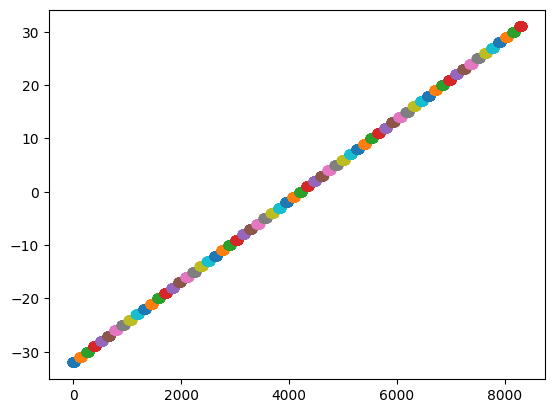

In [34]:
# Plot k-space lines
fig = plt.figure()
ax = plt.axes()

# Loop through the rest of the acquisitions and plot lines
for acqnum in range(firstacq + 1,dset.number_of_acquisitions()): 
    acq = dset.read_acquisition(acqnum)
    ax.scatter(acq.traj[:,0], acq.traj[:,1])
    # print('Acqnum {} has shape {}'.format(acqnum, acq.traj[:,0].shape[0]))

In [35]:
# preallocate storrage
all_data = np.zeros( (nlines, ncoils, nsamples), dtype=np.complex64 )
all_kspace = np.zeros( (nlines, nsamples, 3), dtype=np.complex64 )

# assign
for acqnum in range(firstacq + 1, dset.number_of_acquisitions()):
    acq = dset.read_acquisition(acqnum)
    all_data[acqnum-firstacq-1,:] = acq.data
    all_kspace[acqnum-firstacq-1,:,:] = acq.traj

In [36]:
dset.close()
rawdata = np.squeeze(all_data[:,0,:])

In [37]:
# fftshift FFT fftshift
spectrum = torch.fft.fftshift(torch.from_numpy(rawdata))
space = torch.fft.fft2(spectrum)
space_FA2 = torch.fft.ifftshift(space)


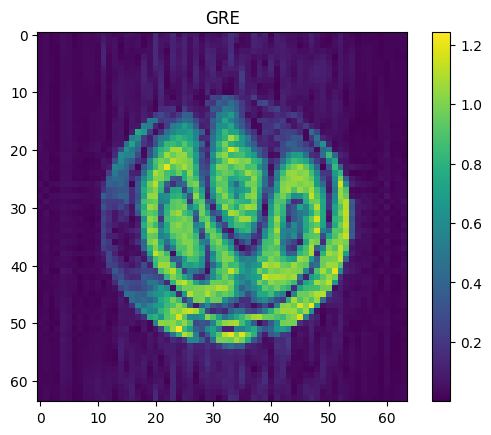

In [38]:
plt.title('GRE')
plt.imshow(np.abs(space_FA2.numpy()))
plt.colorbar()

In [39]:
# compute FA map
r = np.abs(space_FA1.numpy())/np.abs(space_FA2.numpy())
FA_map = np.arccos(1/(2*r))
FA_map[~np.isfinite(FA_map)] = 0 

/var/folders/x0/stdn8c895h99g4y89x6mmbvm0015kg/T/ipykernel_31442/3363120014.py:3: RuntimeWarning: invalid value encountered in arccos
  FA_map = np.arccos(1/(2*r))


In [40]:
thresh = 0.1
Mask = np.zeros_like(FA_map)
Mask[np.abs(space_FA2.numpy()) > thresh * np.max(np.abs(space_FA2.numpy()))] = 1.0

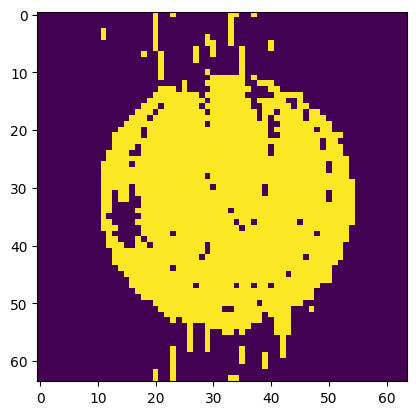

In [41]:
plt.imshow(Mask)

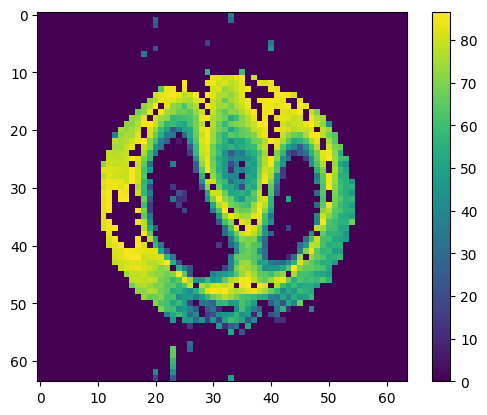

In [42]:
plt.imshow(FA_map*180/np.pi * Mask)
plt.colorbar()

In [43]:
meanFA = np.mean(FA_map[Mask==1.0]*180/np.pi)
print('Mean FA in the masked area is {} degrees.'.format(meanFA))

Mean FA in the masked area is 48.015724182128906 degrees.
